# **MLIS Practical 04**

**Name:** Yesha Pandya  
**Enrollment No:** 23BT04175  
**Division:** A
**Batch**: C

## **Objective:**
To implement a Machine Learning model for classifying the Iris flower dataset using the K-Nearest Neighbors (KNN) classifier in Python

### **NOTE: Overview of Iris Dataset**
The Iris dataset is a benchmark dataset in machine learning introduced by Ronald Fisher in 1936. It consists of 150 samples across 3 target classes:
* Iris-setosa (Class 0)
* Iris-versicolor (Class 1)
* Iris-virginica (Class 2)

Each sample contains 4 features (measured in centimeters):
* Sepal Length
* Sepal Width
* Petal Length
* Petal Width

## **Step 1: Import Libraries + Load Dataset**

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
# Load Iris dataset from scikit-learn
from sklearn.datasets import load_iris
iris = load_iris()

# Create a Pandas DataFrame for easy manipulation
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Display first 5 rows
print("First 5 Rows of Iris Dataset:")
df.head()

First 5 Rows of Iris Dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## **Step 2: EDA + Summary Stats**

In [3]:
print("Dataset Summary Statistics:")
print(df.describe())

print("\nClass Distribution:")
print(df['species'].value_counts())

print("\nMissing Values Check:")
print(df.isnull().sum())

Dataset Summary Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  

Class Distribution:
species
setosa        5

<Figure size 1000x600 with 0 Axes>

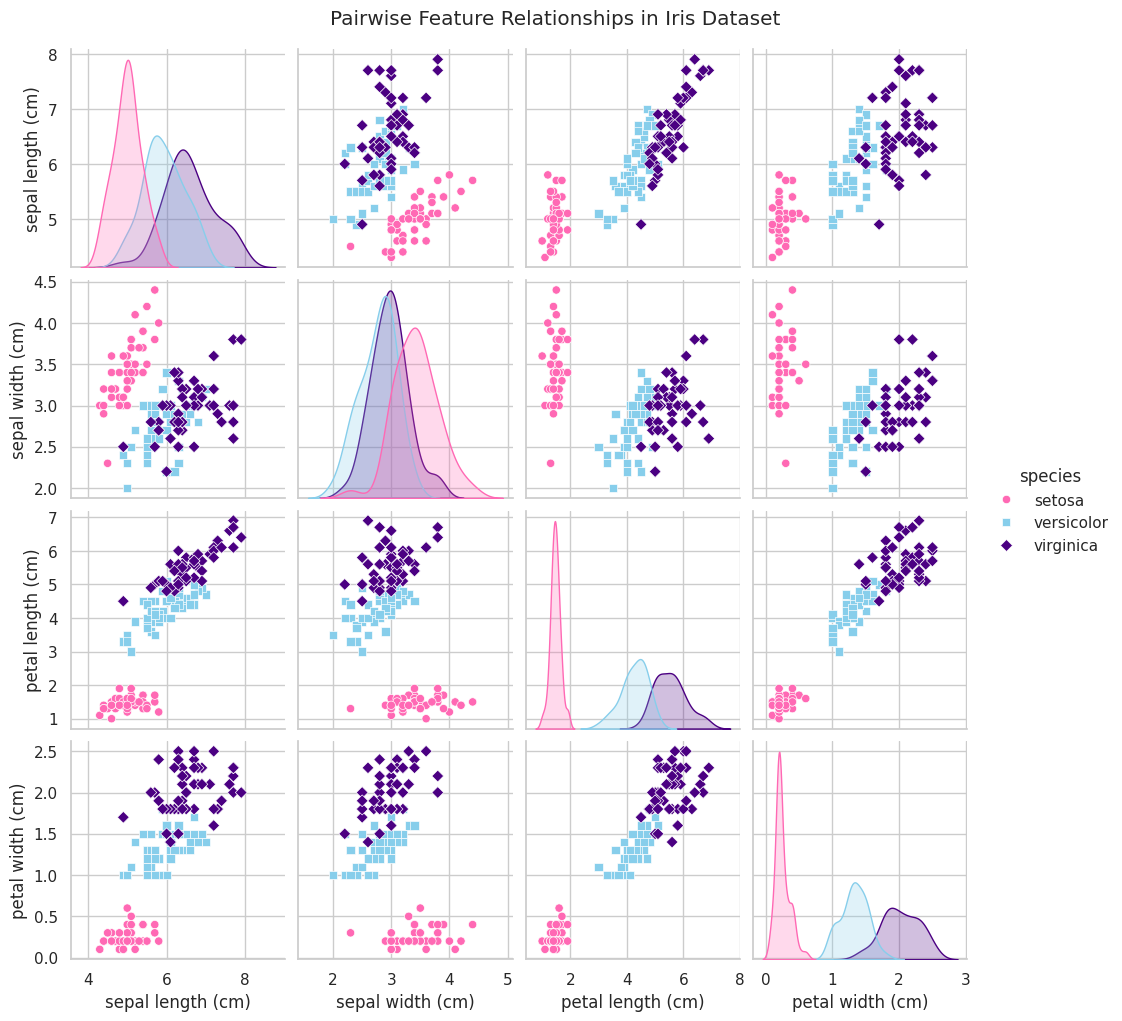

In [9]:
# Feature Distribution Visualization
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Pairwise scatter plot colored by species
sns.pairplot(df.drop(columns=['target']), hue='species', palette=["#FF69B4", "#87CEEB", "#4B0082"], markers=["o", "s", "D"])
plt.suptitle("Pairwise Feature Relationships in Iris Dataset", y=1.02)
plt.show()

Observe that Setosa is linearly separable from the other two species based on petal measurements.

Versicolor and Virginica have slight overlaps in feature space. This makes KNN an ideal non-linear boundary classifier for this dataset.

## **Step 3: Train-Test-split + Feature Scaling**

**NOTE:**
**Why is Feature Scaling Essential for KNN**

Since KNN relies on distance calculations (e.g., Euclidean distance), features with larger ranges/variances will artificially dominate the distance metric.

To eliminate feature bias, we apply Standardization (StandardScaler):

$$z = \frac{x - \mu}{\sigma}$$

Where:
* $x$ is the original feature value
* $\mu$ is the mean of the feature column
* $\sigma$ is the standard deviation

In [5]:
# Extract features (X) and target labels (y)
X = df.iloc[:, :4].values
y = df['target'].values

# Stratified Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Apply Standard Scaling to features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Testing samples:  {X_test_scaled.shape[0]}")

Training samples: 120
Testing samples:  30


## **Step 4: Model Training + Evaluation**

In [13]:
# Initialize model with K=7
knn_model = KNeighborsClassifier(n_neighbors=7, metric='euclidean')

# Fit model on scaled training data
knn_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred = knn_model.predict(X_test_scaled)

# Calculate Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy (K=7): {acc * 100:.2f}%")

Model Accuracy (K=7): 96.67%


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



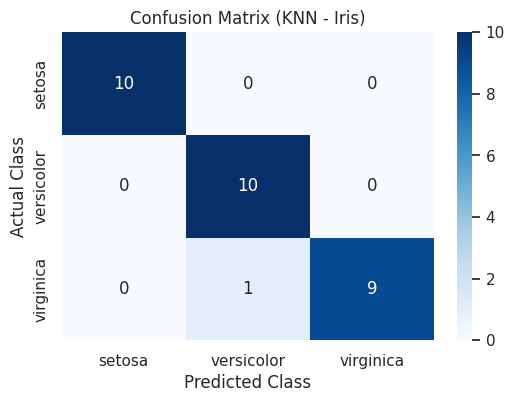

In [14]:
# Detailed Performance Evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("Confusion Matrix (KNN - Iris)")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

## **Step 7: Hyperparameter Tuning (Find Optimal $K$)**
To select the most accurate $K$ value, we iterate through $K = 1$ to $K = 20$ and track error rates.

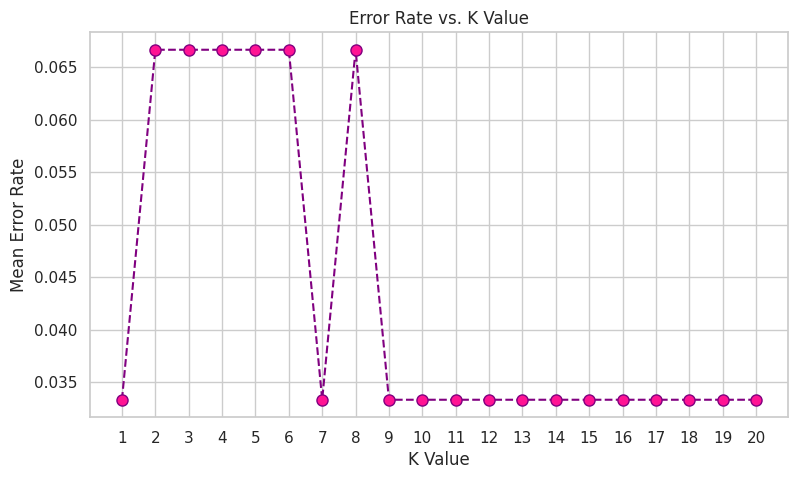

Optimal K Value with Lowest Error Rate: K = 1


In [15]:
error_rate = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred_i = knn.predict(X_test_scaled)
    error_rate.append(np.mean(pred_i != y_test))

# Plotting Error Rate vs K Value
plt.figure(figsize=(9, 5))
plt.plot(range(1, 21), error_rate, color='purple', linestyle='dashed', marker='o',
         markerfacecolor='deeppink', markersize=8)
plt.title('Error Rate vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error Rate')
plt.xticks(range(1, 21))
plt.show()

# Display optimal K
best_k = np.argmin(error_rate) + 1
print(f"Optimal K Value with Lowest Error Rate: K = {best_k}")

## **Results + Discussion**
* **Dataset Characteristics:** The Iris dataset features 150 balanced records without missing values. Petal dimensions exhibit stronger class separability than sepal dimensions.
* **Impact of Scaling:** Feature scaling ensured that feature ranges (e.g., petal length spanning 1.0 to 6.9 cm) did not skew distance measurements over smaller ranges (e.g., sepal width spanning 2.0 to 4.4 cm).
* **Model Performance:** The KNN classifier achieved an accuracy of 96.67% on the unseen 30-sample test set with $K=7$.
* The plot demonstrates that the minimum mean error rate of $0.0333$ (1 classification error out of 30 test samples) is achieved at $K = 7$ and $K \ge 9$.
* So we selected $K = 7$ as the optimal hyperparameter value for this dataset.